# TravelMind ? version rattrapage simple

Cette copie simplifie le projet pour r?pondre aux remarques du jury : moins d'explorations, une finalit? plus lisible et une conclusion assum?e.

Le notebook suit volontairement 6 points :

1. dataset brut ;
2. nettoyage minimal justifi? ;
3. mod?le baseline ;
4. mod?le ML simple ;
5. conclusion claire ;
6. am?lioration continue.

Objectif : pr?dire un **score de satisfaction client de 1 ? 5** avant le d?part, sans utiliser les variables post-voyage (`imprevus`, `reorganisation_necessaire`, `respect_budget`, `retour_client`).

In [1]:
from __future__ import annotations

import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.compose import ColumnTransformer
from sklearn.dummy import DummyRegressor
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import KFold, cross_validate, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

RANDOM_STATE = 42
PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
DATA_PATH = PROJECT_ROOT / "data" / "Examen_travel_planning_dataset.csv"
TARGET = "satisfaction_client"

pd.set_option("display.max_columns", 80)
pd.set_option("display.max_rows", 30)
sns.set_theme(style="whitegrid")

## 1. Dataset brut

Le dataset brut est charg? tel qu'il est fourni. ? ce stade, aucune transformation destructive n'est appliqu?e : l'objectif est de comprendre la source et sa structure avant toute pr?paration.

In [2]:
df_raw = pd.read_csv(DATA_PATH)

print(f"Dimensions du dataset brut : {df_raw.shape[0]} lignes, {df_raw.shape[1]} colonnes")
display(df_raw.head())

description_colonnes = pd.DataFrame({
    "colonne": df_raw.columns,
    "type_initial": df_raw.dtypes.astype(str).values,
    "valeurs_uniques": [df_raw[col].nunique(dropna=True) for col in df_raw.columns],
    "valeurs_manquantes": [df_raw[col].isna().sum() for col in df_raw.columns],
})

display(description_colonnes)

Dimensions du dataset brut : 1500 lignes, 15 colonnes


,trip_id,client_type,budget_total,destination,saison,duree_jours,type_hebergement,prix_vol,meteo_prevue,activite_principale,satisfaction_client,imprevus,reorganisation_necessaire,respect_budget,retour_client
0,1,solo,5548.90,Dubaï,automne,3,hôtel,1320.77,ensoleillé,plage,3.0,annulation,1,0,Séjour mitigé.
1,2,business,3288.27,Rome,printemps,12,hôtel,1524.09,variable,randonnée,4.0,aucun,0,1,Excellent séjour.
2,3,senior,13347.18,Bali,printemps,16,villa,881.94,ensoleillé,plage,5.0,météo,1,1,Excellent séjour.
3,4,couple,7049.42,Sydney,automne,17,appartement,844.39,nuageux,randonnée,3.0,météo,1,1,Séjour mitigé.
4,5,solo,7612.92,Paris,hiver,7,hôtel,1081.24,pluie,gastronomie,2.0,retard_vol,1,1,Séjour mitigé.


,colonne,type_initial,valeurs_uniques,valeurs_manquantes
0,trip_id,int64,1500,0
1,client_type,object,5,0
2,budget_total,float64,1419,40
3,destination,object,8,0
4,saison,object,4,0
5,duree_jours,int64,23,0
6,type_hebergement,object,4,36
7,prix_vol,float64,1429,53
8,meteo_prevue,object,4,39
9,activite_principale,object,5,48


## 2. Nettoyage minimal justifi?

Le nettoyage est volontairement limit? pour ?viter de biaiser le dataset par trop de suppressions ou de r?gles m?tier discutables.

R?gles appliqu?es :

- normaliser les textes : suppression des espaces inutiles et passage en minuscules ;
- convertir les colonnes num?riques au bon format ;
- supprimer uniquement les doublons d'identifiant `trip_id` ;
- conserver uniquement les cibles valides `satisfaction_client` entre `1` et `5` ;
- supprimer les valeurs num?riques impossibles : budget ou prix n?gatif, dur?e hors plage r?aliste ;
- supprimer `prix_vol > budget_total`, car le vol d?passe d?j? le budget total disponible.

R?gles non appliqu?es volontairement : suppression des cas m?tier discutables bas?s sur `imprevus`, `reorganisation_necessaire` ou `satisfaction_client`. Ces suppressions pourraient modifier artificiellement la distribution de la cible.

In [3]:
colonnes_obligatoires = [
    "trip_id",
    "client_type",
    "budget_total",
    "destination",
    "saison",
    "duree_jours",
    "type_hebergement",
    "prix_vol",
    "meteo_prevue",
    "activite_principale",
    TARGET,
]

colonnes_absentes = [col for col in colonnes_obligatoires if col not in df_raw.columns]
if colonnes_absentes:
    raise ValueError(f"Colonnes obligatoires absentes : {colonnes_absentes}")

df_clean = df_raw.copy()
rapport_nettoyage = []

def ajouter_etape(etape, nb_avant, nb_apres, justification):
    rapport_nettoyage.append({
        "etape": etape,
        "lignes_avant": int(nb_avant),
        "lignes_apres": int(nb_apres),
        "lignes_supprimees": int(nb_avant - nb_apres),
        "justification": justification,
    })

nb_avant = len(df_clean)
for col in df_clean.select_dtypes(include=["object", "string"]).columns:
    texte = df_clean[col].astype("string").str.strip().str.lower()
    texte = texte.replace({"": np.nan, "nan": np.nan})
    df_clean[col] = texte.where(texte.notna(), np.nan).astype(object)
ajouter_etape(
    "normalisation_textes",
    nb_avant,
    len(df_clean),
    "Harmoniser les valeurs cat?gorielles sans supprimer de lignes.",
)

for col in ["budget_total", "duree_jours", "prix_vol", TARGET]:
    df_clean[col] = pd.to_numeric(df_clean[col], errors="coerce")

nb_avant = len(df_clean)
df_clean = df_clean.drop_duplicates(subset=["trip_id"], keep="first").copy()
ajouter_etape(
    "unicite_trip_id",
    nb_avant,
    len(df_clean),
    "?viter qu'un m?me s?jour soit compt? plusieurs fois.",
)

nb_avant = len(df_clean)
df_clean = df_clean[df_clean[TARGET].between(1, 5)].copy()
ajouter_etape(
    "cible_satisfaction_1_5",
    nb_avant,
    len(df_clean),
    "La cible doit ?tre pr?sente et comprise entre 1 et 5 pour entra?ner une r?gression.",
)

nb_avant = len(df_clean)
masque_numerique_valide = (
    (df_clean["budget_total"] > 0)
    & (df_clean["duree_jours"].between(1, 90))
    & (df_clean["prix_vol"] >= 0)
)
df_clean = df_clean[masque_numerique_valide].copy()
ajouter_etape(
    "valeurs_numeriques_valides",
    nb_avant,
    len(df_clean),
    "Supprimer uniquement les valeurs impossibles ou hors plage m?tier simple.",
)

nb_avant = len(df_clean)
df_clean = df_clean[df_clean["prix_vol"] <= df_clean["budget_total"]].copy()
ajouter_etape(
    "prix_vol_inferieur_budget_total",
    nb_avant,
    len(df_clean),
    "Le co?t du vol ne doit pas d?passer le budget total disponible.",
)

df_clean = df_clean.reset_index(drop=True)

rapport_nettoyage = pd.DataFrame(rapport_nettoyage)
display(rapport_nettoyage)
print(f"Dataset apr?s nettoyage minimal : {len(df_clean)} lignes")

distribution_cible = (
    df_clean[TARGET]
    .value_counts()
    .sort_index()
    .rename_axis("satisfaction_client")
    .reset_index(name="nombre")
)
distribution_cible["pourcentage"] = (distribution_cible["nombre"] / len(df_clean) * 100).round(2)
display(distribution_cible)

,etape,lignes_avant,lignes_apres,lignes_supprimees,justification
0,normalisation_textes,1500,1500,0,Harmoniser les valeurs cat?gorielles sans supp...
1,unicite_trip_id,1500,1500,0,?viter qu'un m?me s?jour soit compt? plusieurs...
2,cible_satisfaction_1_5,1500,1470,30,La cible doit ?tre pr?sente et comprise entre ...
3,valeurs_numeriques_valides,1470,1383,87,Supprimer uniquement les valeurs impossibles o...
4,prix_vol_inferieur_budget_total,1383,1331,52,Le co?t du vol ne doit pas d?passer le budget ...


Dataset apr?s nettoyage minimal : 1331 lignes


,satisfaction_client,nombre,pourcentage
0,1.0,233,17.51
1,2.0,387,29.08
2,3.0,327,24.57
3,4.0,231,17.36
4,5.0,153,11.50


## 3. Mod?le baseline

La baseline sert de point de comparaison minimal. Ici, elle pr?dit toujours la moyenne de satisfaction du jeu d'entra?nement.

Si un mod?le ML ne fait pas mieux que cette baseline, il n'apporte pas de vraie valeur pr?dictive.

In [4]:
df_model = df_clean.copy()

# Feature engineering volontairement limit? ? des variables disponibles avant le d?part.
df_model["budget_par_jour"] = df_model["budget_total"] / df_model["duree_jours"]
df_model["part_vol_budget"] = df_model["prix_vol"] / df_model["budget_total"]
df_model["sejour_long"] = (df_model["duree_jours"] >= 14).astype(int)
df_model["meteo_risque"] = df_model["meteo_prevue"].isin(["pluie", "variable"]).astype(int)
df_model["client_business"] = (df_model["client_type"] == "business").astype(int)
df_model["hebergement_luxe"] = df_model["type_hebergement"].isin(["resort", "villa"]).astype(int)

features_pre_voyage = [
    "client_type",
    "budget_total",
    "destination",
    "saison",
    "duree_jours",
    "type_hebergement",
    "prix_vol",
    "meteo_prevue",
    "activite_principale",
    "budget_par_jour",
    "part_vol_budget",
    "sejour_long",
    "meteo_risque",
    "client_business",
    "hebergement_luxe",
]

variables_exclues = pd.DataFrame([
    {"variable": "trip_id", "raison": "Identifiant technique sans valeur pr?dictive."},
    {"variable": "imprevus", "raison": "Variable post-voyage, inconnue avant le d?part."},
    {"variable": "reorganisation_necessaire", "raison": "R?sultat op?rationnel post-voyage."},
    {"variable": "respect_budget", "raison": "R?sultat constat? apr?s le s?jour."},
    {"variable": "retour_client", "raison": "Avis post-voyage, trop proche de la satisfaction finale."},
])

display(pd.DataFrame({"variables_entree": features_pre_voyage}))
display(variables_exclues)

X = df_model[features_pre_voyage].copy()
y = df_model[TARGET].astype(float)

for col in X.select_dtypes(include=["object", "string", "category"]).columns:
    X[col] = X[col].where(pd.notna(X[col]), np.nan).astype(object)

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=y.astype(int),
)

numeric_features = X_train.select_dtypes(include="number").columns.tolist()
categorical_features = X_train.select_dtypes(include=["object", "string", "category"]).columns.tolist()

preprocessor = ColumnTransformer([
    ("num", Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
    ]), numeric_features),
    ("cat", Pipeline([
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore")),
    ]), categorical_features),
])

def construire_pipeline(modele):
    return Pipeline([
        ("preprocess", preprocessor),
        ("model", modele),
    ])

def evaluer_modele(nom, modele):
    pipeline = construire_pipeline(modele)
    pipeline.fit(X_train, y_train)
    predictions = np.clip(pipeline.predict(X_test), 1, 5)
    return pipeline, {
        "modele": nom,
        "mae": mean_absolute_error(y_test, predictions),
        "rmse": np.sqrt(mean_squared_error(y_test, predictions)),
        "r2": r2_score(y_test, predictions),
        "prediction_min": predictions.min(),
        "prediction_max": predictions.max(),
    }

pipeline_baseline, metrics_baseline = evaluer_modele(
    "Dummy_mean_baseline",
    DummyRegressor(strategy="mean"),
)

display(pd.DataFrame([metrics_baseline]).round(4))

,variables_entree
0,client_type
1,budget_total
2,destination
3,saison
4,duree_jours
5,type_hebergement
6,prix_vol
7,meteo_prevue
8,activite_principale
9,budget_par_jour


,variable,raison
0,trip_id,Identifiant technique sans valeur pr?dictive.
1,imprevus,"Variable post-voyage, inconnue avant le d?part."
2,reorganisation_necessaire,R?sultat op?rationnel post-voyage.
3,respect_budget,R?sultat constat? apr?s le s?jour.
4,retour_client,"Avis post-voyage, trop proche de la satisfacti..."


,modele,mae,rmse,r2,prediction_min,prediction_max
0,Dummy_mean_baseline,1.0638,1.2552,-0.0,2.7632,2.7632


## 4. Mod?le ML simple

Deux mod?les simples sont test?s :

- `LinearRegression` : mod?le lin?aire de r?f?rence, facile ? expliquer ;
- `RidgeRegression` : r?gression lin?aire r?gularis?e, plus stable quand il y a plusieurs variables encod?es.

Les traitements qui apprennent des param?tres (`imputation`, `standardisation`, `OneHotEncoder`) sont int?gr?s au pipeline et appris uniquement sur le jeu d'entra?nement.

In [5]:
modeles = {
    "Dummy_mean_baseline": DummyRegressor(strategy="mean"),
    "LinearRegression": LinearRegression(),
    "RidgeRegression": Ridge(alpha=1.0),
}

resultats = []
pipelines = {}
for nom, modele in modeles.items():
    pipeline, metrics = evaluer_modele(nom, modele)
    pipelines[nom] = pipeline
    resultats.append(metrics)

resultats_modeles = (
    pd.DataFrame(resultats)
    .sort_values(["mae", "rmse"])
    .reset_index(drop=True)
)

baseline_mae = resultats_modeles.loc[
    resultats_modeles["modele"] == "Dummy_mean_baseline",
    "mae",
].iloc[0]
resultats_modeles["gain_mae_vs_baseline"] = baseline_mae - resultats_modeles["mae"]

display(resultats_modeles.round(4))

modele_retenu = resultats_modeles.iloc[0]["modele"]
print("Meilleur mod?le selon la MAE :", modele_retenu)

,modele,mae,rmse,r2,prediction_min,prediction_max,gain_mae_vs_baseline
0,RidgeRegression,1.0579,1.2555,-0.0004,2.0919,3.9535,0.0059
1,LinearRegression,1.0582,1.2559,-0.0011,2.0876,3.9514,0.0055
2,Dummy_mean_baseline,1.0638,1.2552,-0.0000,2.7632,2.7632,0.0000


Meilleur mod?le selon la MAE : RidgeRegression


In [6]:
cv = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
resultats_cv = []

for nom, modele in modeles.items():
    scores = cross_validate(
        construire_pipeline(modele),
        X,
        y,
        cv=cv,
        scoring={
            "mae": "neg_mean_absolute_error",
            "rmse": "neg_root_mean_squared_error",
            "r2": "r2",
        },
        n_jobs=1,
    )
    resultats_cv.append({
        "modele": nom,
        "cv_mae_moyenne": -scores["test_mae"].mean(),
        "cv_mae_ecart_type": scores["test_mae"].std(),
        "cv_rmse_moyenne": -scores["test_rmse"].mean(),
        "cv_r2_moyen": scores["test_r2"].mean(),
    })

resultats_cv = pd.DataFrame(resultats_cv).sort_values("cv_mae_moyenne").reset_index(drop=True)
display(resultats_cv.round(4))

,modele,cv_mae_moyenne,cv_mae_ecart_type,cv_rmse_moyenne,cv_r2_moyen
0,Dummy_mean_baseline,1.0626,0.0289,1.2544,-0.0104
1,RidgeRegression,1.0641,0.0437,1.2662,-0.0295
2,LinearRegression,1.0644,0.0438,1.2667,-0.0302


## 5. Conclusion claire

Cette version simple permet de r?pondre directement ? la question du jury : le mod?le apprend-il r?ellement quelque chose d'utile ? partir des variables pr?-voyage actuelles ?

La r?ponse est prudente : le pipeline est propre, mais la performance reste proche de la baseline. Le mod?le ne doit donc pas ?tre pr?sent? comme une aide ? la d?cision fiable en l'?tat.

,point,resultat,interpretation
0,Performance baseline,MAE = 1.0638,Erreur moyenne si on pr?dit toujours la moyenne.
1,Meilleur mod?le simple,RidgeRegression ; MAE = 1.0579 ; R2 = -0.0004,Le gain est tr?s faible par rapport ? la basel...
2,D?cision m?tier,Non mise en production d?cisionnelle,Le mod?le sert de prototype technique et de ba...


,satisfaction_reelle,nb_lignes,mae,prediction_moyenne
0,1.0,47,1.7778,2.7778
1,2.0,78,0.7323,2.7323
2,3.0,65,0.2951,2.7719
3,4.0,46,1.2313,2.7687
4,5.0,31,2.1274,2.8726


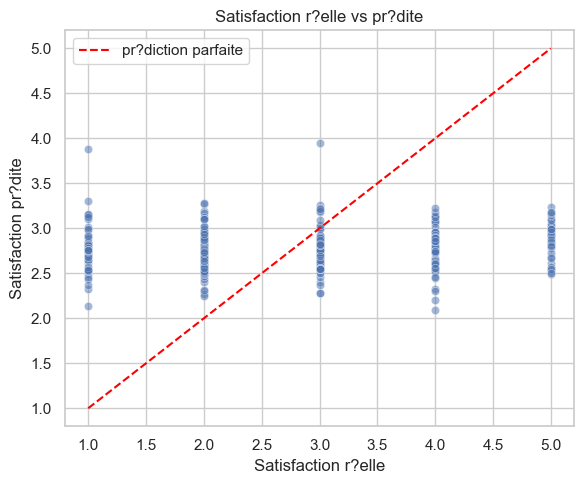

In [7]:
meilleur = resultats_modeles.iloc[0]
baseline = resultats_modeles[resultats_modeles["modele"] == "Dummy_mean_baseline"].iloc[0]

synthese_decision = pd.DataFrame([
    {
        "point": "Performance baseline",
        "resultat": f"MAE = {baseline['mae']:.4f}",
        "interpretation": "Erreur moyenne si on pr?dit toujours la moyenne.",
    },
    {
        "point": "Meilleur mod?le simple",
        "resultat": f"{meilleur['modele']} ; MAE = {meilleur['mae']:.4f} ; R2 = {meilleur['r2']:.4f}",
        "interpretation": "Le gain est tr?s faible par rapport ? la baseline.",
    },
    {
        "point": "D?cision m?tier",
        "resultat": "Non mise en production d?cisionnelle",
        "interpretation": "Le mod?le sert de prototype technique et de base d'am?lioration, pas de score client fiable.",
    },
])

display(synthese_decision)

predictions_retenues = np.clip(pipelines[modele_retenu].predict(X_test), 1, 5)
evaluation = pd.DataFrame({
    "satisfaction_reelle": y_test.to_numpy(),
    "satisfaction_predite": predictions_retenues,
})
evaluation["erreur_absolue"] = (evaluation["satisfaction_reelle"] - evaluation["satisfaction_predite"]).abs()

erreurs_par_note = (
    evaluation
    .groupby("satisfaction_reelle")
    .agg(
        nb_lignes=("erreur_absolue", "size"),
        mae=("erreur_absolue", "mean"),
        prediction_moyenne=("satisfaction_predite", "mean"),
    )
    .reset_index()
)

display(erreurs_par_note.round(4))

plt.figure(figsize=(6, 5))
sns.scatterplot(data=evaluation, x="satisfaction_reelle", y="satisfaction_predite", alpha=0.5)
plt.plot([1, 5], [1, 5], linestyle="--", color="red", label="pr?diction parfaite")
plt.title("Satisfaction r?elle vs pr?dite")
plt.xlabel("Satisfaction r?elle")
plt.ylabel("Satisfaction pr?dite")
plt.xlim(0.8, 5.2)
plt.ylim(0.8, 5.2)
plt.legend()
plt.tight_layout()
plt.show()

## 6. Am?lioration continue

La priorit? n'est pas d'ajouter davantage de traitements, mais de collecter de meilleures donn?es avant le d?part.

| Axe | Action propos?e | Utilit? |
| --- | --- | --- |
| Donn?es r?elles | Ajouter qualit? h?tel, dur?e de vol, nombre d'escales, historique m?t?o, avis destination | Augmenter le signal disponible avant d?part |
| Retours clients | Collecter la satisfaction r?elle apr?s s?jour | Mesurer la performance en production |
| Monitoring | Suivre drift, MAE r?elle, erreurs par segment | D?tecter une d?gradation du mod?le |
| R?entra?nement | D?clencher si nouvelles donn?es suffisantes ou baisse de performance | Maintenir le mod?le ? jour |
| Promotion mod?le | Comparer nouveau mod?le vs mod?le actuel avant remplacement | ?viter de d?ployer un mod?le moins bon |
| Documentation | G?n?rer Model Card, m?triques et journal des versions | Garantir tra?abilit? et transparence |

Conclusion finale : cette version simple montre que les variables pr?-voyage actuelles ne suffisent pas ? produire un mod?le performant. Le projet reste pertinent comme prototype industrialisable, mais la vraie am?lioration d?pendra de donn?es m?tier r?elles plus explicatives.